Yesterday's analysis was with all data, today I want to focus only on the scattering spectra of the raw samples.

# 1. Visualization of the absorption, scattering and beam attenuation for all samples

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

labdata_path = "../data/raw/3_laboratory_measurements"

lab_data = pd.read_csv(os.path.join(labdata_path, "sample_s01-s24.csv"))
lab_data["tss_mg_l"] = lab_data["ss_04u_mg_l"] + lab_data["ss_14u_mg_l"]
lab_data_cols_order = ['sample', 'tur_raw_ntu', 'tur_04u_ntu', 'tur_14u_ntu', 'tss_mg_l', 'ss_04u_mg_l',
       'ss_14u_mg_l', 'tp_raw_mg_l', 'tdp_14u_mg_l', 'tdp_04u_mg_l',
       'toc_raw_mg_l', 'doc_14u_mg_l', 'doc_04u_mg_l', 'tn_raw_mg_l',
       'tdn_14u_mg_l', 'tdn_04u_mg_l', ]
lab_data = lab_data[lab_data_cols_order]

metadata = pd.read_csv(os.path.join(labdata_path, "sample_metadata.csv"))
lab_data = metadata.merge(lab_data)


acsdata_path = "../data/processed/"

spectra_B_df = pd.read_csv(os.path.join(acsdata_path,"2026-03-04_acs_b_clean_df.csv"), index_col="index")
sp_cols_B = spectra_B_df.columns[23:]
wav_B = np.array(sp_cols_B.astype("float"))
spectra_B_df = lab_data.merge(spectra_B_df)

spectra_B_df = spectra_B_df[spectra_B_df["preprocessing"]=="raw"]

# 1. Scattering coeff power law fit

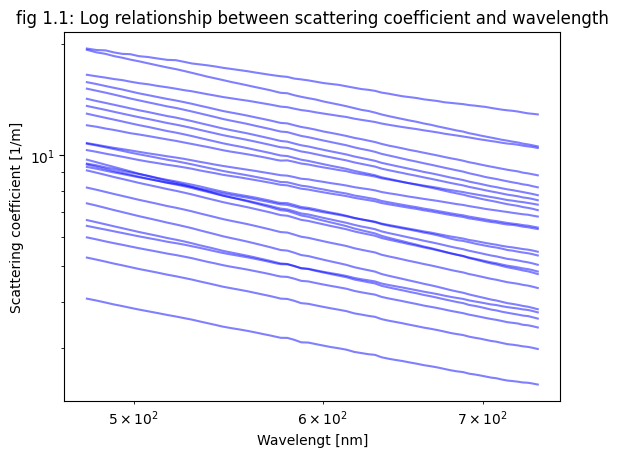

In [56]:
for (i, sample_data) in spectra_B_df.iterrows():
    plt.plot(wav_B, sample_data[sp_cols_B], color="blue", alpha=0.5)

plt.xscale("log"), 
plt.yscale("log")
plt.ylabel("Scattering coefficient [1/m]")
plt.xlabel("Wavelengt [nm]")
plt.title("fig 1.1: Log relationship between scattering coefficient and wavelength")
plt.show()

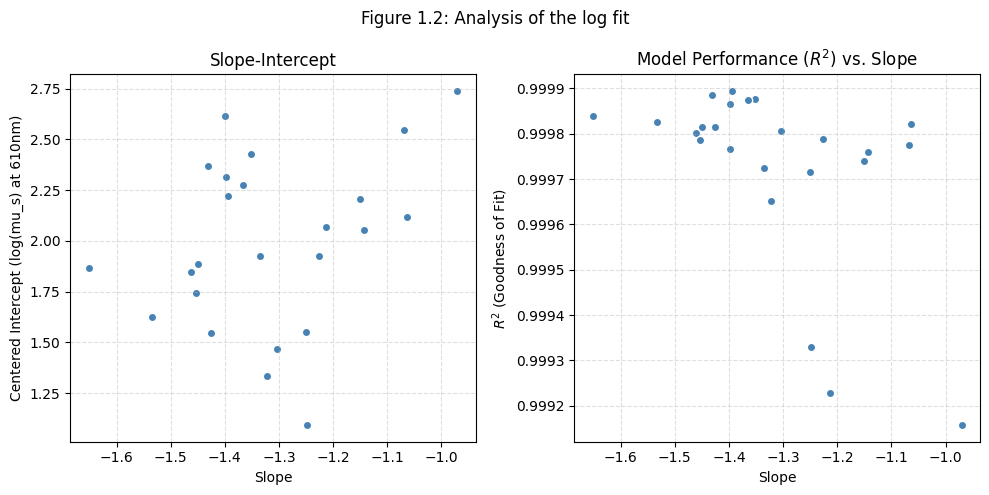

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

wav_ref = np.mean(wav_B)
fig, ax = plt.subplots(ncols=2, figsize=(10, 5))

marker_color = "steelblue" 

for (i, sample_data) in spectra_B_df.iterrows():
    try:
        y_values = sample_data[sp_cols_B].values.astype(float)
        
        # Centered log-log fit
        x_centered = np.log(wav_B / wav_ref)
        y_log = np.log(y_values)
        
        # Fit the model
        slope, centered_intercept = np.polyfit(x_centered, y_log, 1)
        
        # Calculate Goodness of Fit (R-squared)
        y_pred_log = slope * x_centered + centered_intercept
        r_squared = r2_score(y_log, y_pred_log)
        
        # Plot 1: Slope vs Centered Intercept (Physical Independence)
        ax[0].scatter(slope, centered_intercept, color=marker_color, edgecolors='w')
        
        # Plot 2: Slope vs R-squared (Checking fit quality across different particle types)
        # This helps you see if certain "slopes" (particle sizes) are harder to fit accurately
        ax[1].scatter(slope, r_squared, color=marker_color, edgecolors='w')

    except Exception as e:
        print(f"Error processing row {i}: {e}")

# Formatting Plot 0: Physical parameters
ax[0].set_xlabel('Slope')
ax[0].set_ylabel(f'Centered Intercept (log(mu_s) at {wav_ref:.0f}nm)')
ax[0].set_title('Slope-Intercept')
ax[0].grid(True, linestyle='--', alpha=0.4)

# Formatting Plot 1: Quality Control
ax[1].set_xlabel('Slope')
ax[1].set_ylabel('$R^2$ (Goodness of Fit)')
ax[1].set_title('Model Performance ($R^2$) vs. Slope')
ax[1].grid(True, linestyle='--', alpha=0.4)

fig.suptitle("Figure 1.2: Analysis of the log fit")
plt.tight_layout()
plt.show()

As explained in the previous notebook, to avoid the articicial slope-intercept correlation, it is a good idea to transform the x-axis to center around a reference wavelength (here I took the mean). The centered intercept then corresponds to the scattering value at the reference wavelength. 

Given figure 1.1, it makes sense that the fit has a very high r2. But it also validates the quality of the data.

# 2. Correlation matrix between slope, centered intercept, and the laboratory measurements

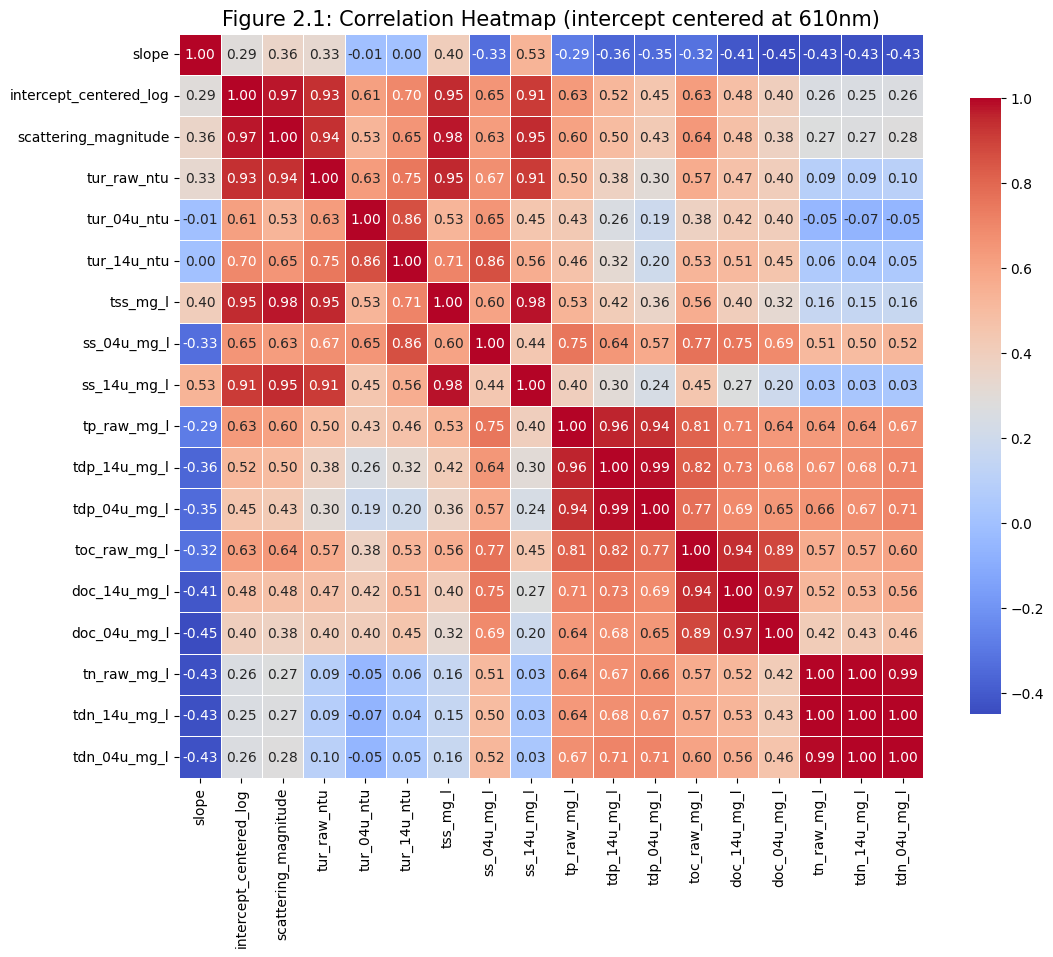

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

slope_intercept_lst = []

# 1. Define a reference wavelength to "center" the data
# This is the key to breaking the 0.9 correlation between slope and intercept.
wav_ref = np.mean(wav_B)

for (i, sample_data) in spectra_B_df.iterrows():
    try:
        full_sample_name = sample_data["full_sample_name"]
        y_values = sample_data[sp_cols_B].values.astype(float)
        
        # Ensure values are positive before logging
        mask = (y_values > 0) & (wav_B > 0)
        
        # --- THE FIX: Centered log-log fit ---
        # We fit: ln(y) = slope * ln(wav / wav_ref) + centered_intercept
        x_centered = np.log(wav_B[mask] / wav_ref)
        y_log = np.log(y_values[mask])
        
        slope, centered_intercept = np.polyfit(x_centered, y_log, 1)
        
        slope_intercept_lst.append({
            "full_sample_name": full_sample_name,
            "slope": slope, 
            "intercept_centered_log": centered_intercept,
            "scattering_magnitude": np.exp(centered_intercept) 
        })

    except Exception as e:
        print(f"ERROR on {full_sample_name}: {type(e).__name__} - {e}")

# Merge the new parameters back into the original dataframe
results_df = pd.DataFrame(slope_intercept_lst)
spectra_merged_df = results_df.merge(spectra_B_df, on="full_sample_name")

# 2. Select columns for Correlation Analysis
# We include the slope, the centered intercept, and the scattering magnitude
new_cols = ["slope", "intercept_centered_log", "scattering_magnitude"]
lab_param_cols = list(spectra_merged_df.columns[10:25]) # Adjust indices if needed
cols_for_corr_analysis = new_cols + lab_param_cols

# 3. Calculate and Plot Heatmap
corr_matrix = spectra_merged_df[cols_for_corr_analysis].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    square=True, 
    linewidths=0.5, 
    cbar_kws={"shrink": .8}
)

plt.title(f'Figure 2.1: Correlation Heatmap (intercept centered at {wav_ref:.0f}nm)', fontsize=15)
plt.show()

We see in figure 2.1 that the intercept (and the scattering magnitude, which is just the exponential of the scattering magnitude), correlate well with tss and raw tuerbidit. The slope does not correlate strongly with any variable. Next I will try to build simple models to predict the slope and centered intercept.
# 3. Models to predict the scattering magnitude
## 3.1. Model with all features

--- MLR Results ---
Magnitude: -1.2040
         Feature  Coefficient
0       dilution     0.000000
1    tur_raw_ntu     0.381998
2    tur_04u_ntu     0.179942
3    tur_14u_ntu     0.421861
4       tss_mg_l    -0.125234
5    ss_04u_mg_l    -0.823278
6    ss_14u_mg_l     0.698043
7    tp_raw_mg_l     7.228792
8   tdp_14u_mg_l     4.060954
9   tdp_04u_mg_l   -11.158400
10  toc_raw_mg_l     0.025985
11  doc_14u_mg_l    -0.035731
12  doc_04u_mg_l     0.027409
13   tn_raw_mg_l     0.204796
14  tdn_14u_mg_l    -0.150149
R² Score: 0.990
RMSE: 0.3192


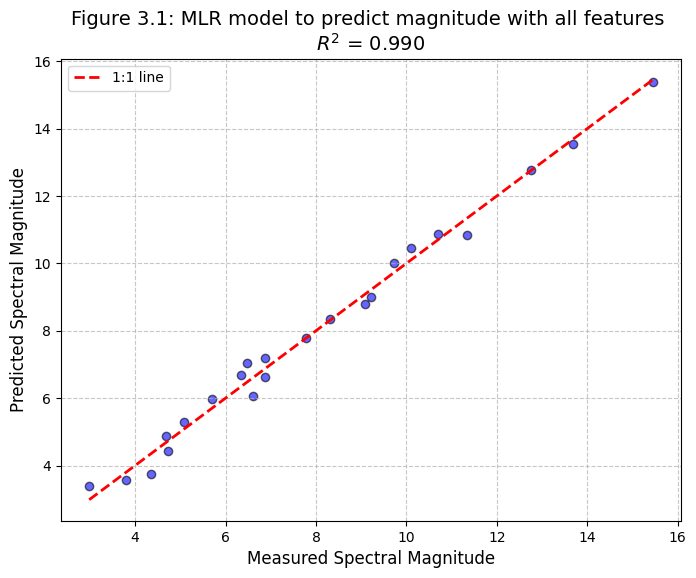

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Define Features (X) and Target (y)
# Using 'toc' based on your previous dictionary keys
features = list(spectra_merged_df.columns[9:24])

# Create a cleaned version of the dataframe
res_df_clean = spectra_merged_df.dropna(subset=features+["scattering_magnitude"])

# Re-run the model using the cleaned data
X = res_df_clean[features]
y = res_df_clean['scattering_magnitude']

magnitude_model = LinearRegression()
magnitude_model.fit(X, y)

# 2. Initialize and Train the Model on the full dataset
magnitude_model = LinearRegression()
magnitude_model.fit(X, y)

# 3. Generate Predictions for the same dataset
y_pred = magnitude_model.predict(X)

# 4. Calculate Fit Metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

# 5. Display Coefficients and Intercept
print(f"--- MLR Results ---")
print(f"Magnitude: {magnitude_model.intercept_:.4f}")
coeff_df = pd.DataFrame({'Feature': features, 'Coefficient': magnitude_model.coef_})
print(coeff_df)
print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.4f}")

# 6. Parity Plot: Actual vs. Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='blue', alpha=0.6, edgecolors='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label="1:1 line")

plt.title(f'Figure 3.1: MLR model to predict magnitude with all features \n$R^2$ = {r2:.3f}', fontsize=14)
plt.xlabel('Measured Spectral Magnitude', fontsize=12)
plt.ylabel('Predicted Spectral Magnitude', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

As expected, the model is almost perfect. Now let's develop a simple, single parameter model
## 3.2. Single feature model

Selected Single Variable: tss_mg_l (Correlation: 0.977)


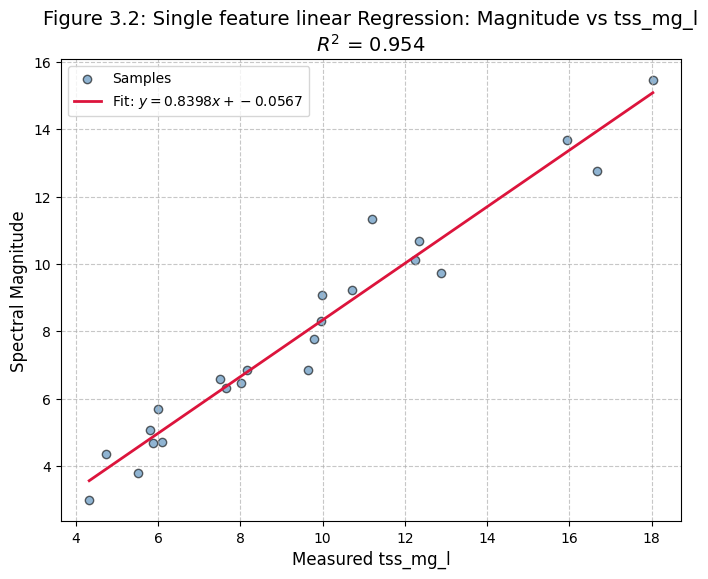

--- Simple Regression Results ---
Feature: tss_mg_l
Equation: Magnitude = (0.8398 * tss_mg_l) + -0.0567
R² Score: 0.954


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 1. Select your single best feature
# You can manually set this (e.g., target_feature = "toc") 
# or use the one with the highest correlation:
features = list(spectra_merged_df.columns[9:24])
correlations = spectra_merged_df[features + ['scattering_magnitude']].corr()['scattering_magnitude'].abs().drop('scattering_magnitude')
target_feature = correlations.idxmax() 

print(f"Selected Single Variable: {target_feature} (Correlation: {correlations[target_feature]:.3f})")

# 2. Clean data for this specific pair
res_df_clean = spectra_merged_df.dropna(subset=[target_feature, "scattering_magnitude"])

# 3. Prepare X and y 
# X must be 2D for scikit-learn (.values.reshape(-1, 1))
X = res_df_clean[[target_feature]].values
y = res_df_clean['scattering_magnitude'].values

# 4. Train the Simple Model
magnitude_model = LinearRegression()
magnitude_model.fit(X, y)

# 5. Generate Predictions
y_pred = magnitude_model.predict(X)

# 6. Metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

# 7. Visualization: Regression Line vs Data
plt.figure(figsize=(8, 6))

# Plot the raw data points
plt.scatter(X, y, color='steelblue', alpha=0.6, edgecolors='k', label='Samples')

# Plot the regression line
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_range_pred = magnitude_model.predict(X_range)
plt.plot(X_range, y_range_pred, color='crimson', lw=2, label=f'Fit: $y = {magnitude_model.coef_[0]:.4f}x + {magnitude_model.intercept_:.4f}$')

plt.title(f'Figure 3.2: Single feature linear Regression: Magnitude vs {target_feature}\n$R^2$ = {r2:.3f}', fontsize=14)
plt.xlabel(f'Measured {target_feature}', fontsize=12)
plt.ylabel('Spectral Magnitude', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"--- Simple Regression Results ---")
print(f"Feature: {target_feature}")
print(f"Equation: Magnitude = ({magnitude_model.coef_[0]:.4f} * {target_feature}) + {magnitude_model.intercept_:.4f}")
print(f"R² Score: {r2:.3f}")

A single feature model using tss is already excellent. 
# 4. Model to predict the slope
## 4.1. Model with all features

--- MLR Results ---
Intercept: -1.3627
         Feature  Coefficient
0       dilution     0.000000
1    tur_raw_ntu     0.026438
2    tur_04u_ntu    -0.550487
3    tur_14u_ntu     0.148311
4       tss_mg_l    -0.020945
5    ss_04u_mg_l    -0.077041
6    ss_14u_mg_l     0.056096
7    tp_raw_mg_l     0.216665
8   tdp_14u_mg_l    -4.772945
9   tdp_04u_mg_l     4.768201
10  toc_raw_mg_l    -0.005560
11  doc_14u_mg_l     0.007266
12  doc_04u_mg_l    -0.001289
13   tn_raw_mg_l     0.053641
14  tdn_14u_mg_l    -0.054762
R² Score: 0.858
RMSE: 0.0601


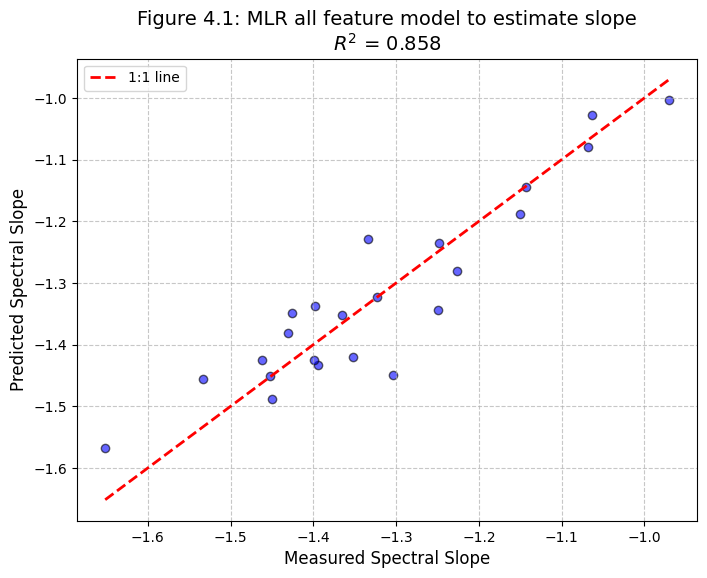

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Define Features (X) and Target (y)
# Using 'toc' based on your previous dictionary keys
features = list(spectra_merged_df.columns[9:24])

# Create a cleaned version of the dataframe
res_df_clean = spectra_merged_df.dropna(subset=features+["slope"])

# Re-run the model using the cleaned data
X = res_df_clean[features]
y = res_df_clean['slope']

magnitude_model = LinearRegression()
magnitude_model.fit(X, y)

# 2. Initialize and Train the Model on the full dataset
magnitude_model = LinearRegression()
magnitude_model.fit(X, y)

# 3. Generate Predictions for the same dataset
y_pred = magnitude_model.predict(X)

# 4. Calculate Fit Metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

# 5. Display Coefficients and Intercept
print(f"--- MLR Results ---")
print(f"Intercept: {magnitude_model.intercept_:.4f}")
coeff_df = pd.DataFrame({'Feature': features, 'Coefficient': magnitude_model.coef_})
print(coeff_df)
print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.4f}")

# 6. Parity Plot: Actual vs. Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='blue', alpha=0.6, edgecolors='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label="1:1 line")

plt.title(f'Figure 4.1: MLR all feature model to estimate slope\n$R^2$ = {r2:.3f}', fontsize=14)
plt.xlabel('Measured Spectral Slope', fontsize=12)
plt.ylabel('Predicted Spectral Slope', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

the model is surprisingly good. Either it overfits, or the features interact in a way related to the scattering coefficient. 
## 4.2. Single feature model

Selected Single Variable: ss_14u_mg_l (Correlation: 0.531)


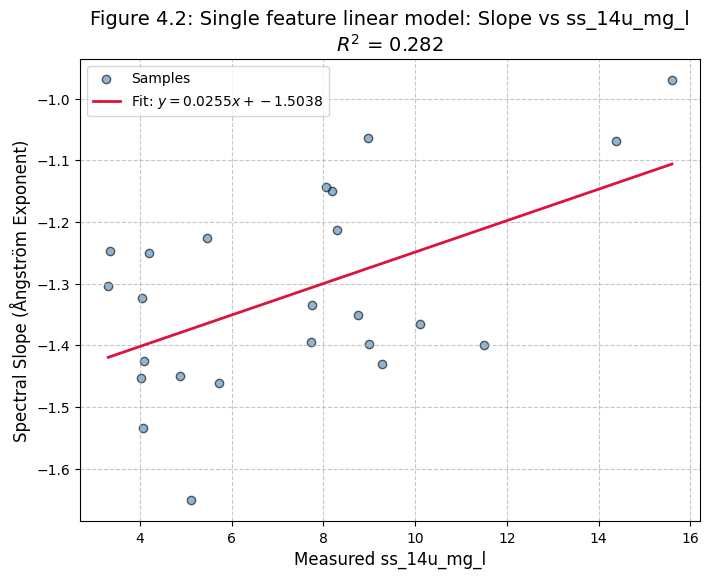

--- Simple Regression Results ---
Feature: ss_14u_mg_l
Equation: Slope = (0.0255 * ss_14u_mg_l) + -1.5038
R² Score: 0.282


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 1. Select your single best feature
# You can manually set this (e.g., target_feature = "toc") 
# or use the one with the highest correlation:
features = list(spectra_merged_df.columns[9:24])
correlations = spectra_merged_df[features + ['slope']].corr()['slope'].abs().drop('slope')
target_feature = correlations.idxmax() 

print(f"Selected Single Variable: {target_feature} (Correlation: {correlations[target_feature]:.3f})")

# 2. Clean data for this specific pair
res_df_clean = spectra_merged_df.dropna(subset=[target_feature, "slope"])

# 3. Prepare X and y 
# X must be 2D for scikit-learn (.values.reshape(-1, 1))
X = res_df_clean[[target_feature]].values
y = res_df_clean['slope'].values

# 4. Train the Simple Model
magnitude_model = LinearRegression()
magnitude_model.fit(X, y)

# 5. Generate Predictions
y_pred = magnitude_model.predict(X)

# 6. Metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

# 7. Visualization: Regression Line vs Data
plt.figure(figsize=(8, 6))

# Plot the raw data points
plt.scatter(X, y, color='steelblue', alpha=0.6, edgecolors='k', label='Samples')

# Plot the regression line
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_range_pred = magnitude_model.predict(X_range)
plt.plot(X_range, y_range_pred, color='crimson', lw=2, label=f'Fit: $y = {magnitude_model.coef_[0]:.4f}x + {magnitude_model.intercept_:.4f}$')

plt.title(f'Figure 4.2: Single feature linear model: Slope vs {target_feature}\n$R^2$ = {r2:.3f}', fontsize=14)
plt.xlabel(f'Measured {target_feature}', fontsize=12)
plt.ylabel('Spectral Slope (Ångström Exponent)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"--- Simple Regression Results ---")
print(f"Feature: {target_feature}")
print(f"Equation: Slope = ({magnitude_model.coef_[0]:.4f} * {target_feature}) + {magnitude_model.intercept_:.4f}")
print(f"R² Score: {r2:.3f}")

As anticipated by the correlation matrix (figure 2.1), a single feature is not able to explain the slope.
## 4.3. Brute-force looking for the best combination of 1, 2, 3, and 4 features

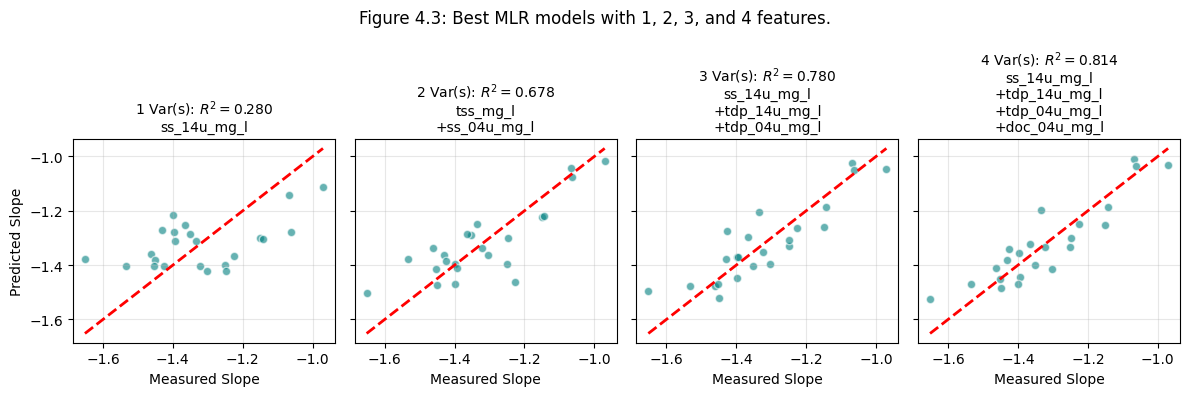

Best 1-Var Model: ('ss_14u_mg_l',) | R2: 0.2796
Best 2-Var Model: ('tss_mg_l', 'ss_04u_mg_l') | R2: 0.6778
Best 3-Var Model: ('ss_14u_mg_l', 'tdp_14u_mg_l', 'tdp_04u_mg_l') | R2: 0.7800
Best 4-Var Model: ('ss_14u_mg_l', 'tdp_14u_mg_l', 'tdp_04u_mg_l', 'doc_04u_mg_l') | R2: 0.8137


In [ ]:
import itertools
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import pandas as pd


# 1. Define Features (X) and Target (y)
# Using 'toc' based on your previous dictionary keys
features = list(spectra_merged_df.columns[9:24])

# Create a cleaned version of the dataframe
res_df_clean = spectra_merged_df.dropna(subset=features+["slope"])

# Re-run the model using the cleaned data
X = res_df_clean[features]
y = res_df_clean['slope']

best_models = {}

# Test for 1, 2, and 3 variables
for k in [1, 2, 3, 4]:
    best_r2 = -1
    best_comb = None
    
    # Generate all combinations of size k
    for combo in itertools.combinations(features, k):
        X_sub = res_df_clean[list(combo)]
        
        magnitude_model = LinearRegression().fit(X_sub, y)
        r2 = r2_score(y, magnitude_model.predict(X_sub))
        
        if r2 > best_r2:
            best_r2 = r2
            best_comb = combo
            
    best_models[k] = (best_comb, best_r2)

# --- Plotting the Results ---
fig, axes = plt.subplots(1, 4, figsize=(12, 4), sharey=True)

for i, k in enumerate([1, 2, 3, 4]):
    combo, r2 = best_models[k]
    X_best = res_df_clean[list(combo)]
    magnitude_model = LinearRegression().fit(X_best, y)
    y_pred = magnitude_model.predict(X_best)
    
    axes[i].scatter(y, y_pred, alpha=0.6, color='teal', edgecolors='w')
    axes[i].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    
    # Create title with feature names
    title_features = "\n+".join(combo)
    axes[i].set_title(f"{k} Var(s): $R^2 = {r2:.3f}$\n{title_features}", fontsize=10)
    axes[i].set_xlabel('Measured Slope')
    if i == 0: axes[i].set_ylabel('Predicted Slope')
    axes[i].grid(True, alpha=0.3)
    
fig.suptitle("Figure 4.3: Best MLR models with 1, 2, 3, and 4 features.")
plt.tight_layout()
plt.show()

# Print summary
for k, (combo, r2) in best_models.items():
    print(f"Best {k}-Var Model: {combo} | R2: {r2:.4f}")

Results are very promising and show how combining information about the particules and the solubles compounds leads to a good model for the slope. 
# 4.4. Simplest MLR model with only common features. 
In the final analysis, I want to limit the features to the most common ones, to create a model that could be applicable to many dataset, including historical data. Therefore I only used the raw and the 04u measurements. To add more features, I also calculated the all possible ratios and the log values.

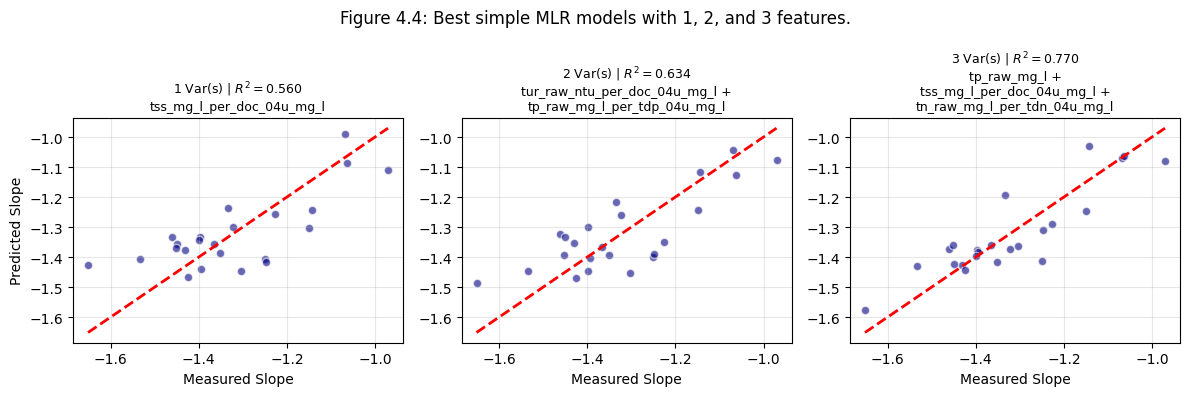

In [ ]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Setup Feature Generation
commonly_measured_variables = [
    'tur_raw_ntu', 'tss_mg_l', 'tp_raw_mg_l', 'tdp_04u_mg_l',
    'toc_raw_mg_l', 'doc_04u_mg_l', 'tn_raw_mg_l', 'tdn_04u_mg_l'
]

# Create a temporary copy to work with
df_eng = res_df_clean.copy()
new_features = []

# Generate Logs
for col in commonly_measured_variables:
    log_name = f"log_{col}"
    df_eng[log_name] = np.log(df_eng[col].replace(0, np.nan)) # Avoid log(0)
    new_features.append(log_name)

# Generate Ratios
for col1, col2 in itertools.combinations(commonly_measured_variables, 2):
    ratio_name = f"{col1}_per_{col2}"
    df_eng[ratio_name] = df_eng[col1] / df_eng[col2].replace(0, np.nan) # Avoid div by zero
    new_features.append(ratio_name)

# Combine all potential features
all_eng_features = commonly_measured_variables + new_features

# 2. Final Cleaning
# Drop columns that are entirely NaN and rows with any remaining NaNs in the new features
df_eng = df_eng.dropna(subset=all_eng_features + ['slope'])
# Replace infinity with NaN and drop (if any survived)
df_eng = df_eng.replace([np.inf, -np.inf], np.nan).dropna(subset=all_eng_features)

X_all = df_eng[all_eng_features]
y = df_eng['slope']

# 3. Brute Force Optimization (Best 1, 2, 3)
best_results = {}

for k in [1, 2, 3]:
    best_r2 = -1
    best_comb = None
    
    # We use all_eng_features pool now
    for combo in itertools.combinations(all_eng_features, k):
        X_sub = df_eng[list(combo)]
        magnitude_model = LinearRegression().fit(X_sub, y)
        r2 = r2_score(y, magnitude_model.predict(X_sub))
        
        if r2 > best_r2:
            best_r2 = r2
            best_comb = combo
            
    best_results[k] = (best_comb, best_r2)

# 4. Plotting
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, k in enumerate([1, 2, 3]):
    combo, r2 = best_results[k]
    X_plot = df_eng[list(combo)]
    magnitude_model = LinearRegression().fit(X_plot, y)
    y_pred = magnitude_model.predict(X_plot)
    
    axes[i].scatter(y, y_pred, color='navy', alpha=0.6, edgecolors='white')
    axes[i].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    
    title_text = f"{k} Var(s) | $R^2 = {r2:.3f}$\n" + " +\n".join(combo)
    axes[i].set_title(title_text, fontsize=9)
    axes[i].set_xlabel('Measured Slope')
    if i == 0: axes[i].set_ylabel('Predicted Slope')
    axes[i].grid(True, alpha=0.3)

fig.suptitle("Figure 4.4: Best simple MLR models with 1, 2, and 3 features.")

plt.tight_layout()
plt.show()

# 5. Summary of the best models

<>:40: SyntaxWarning: invalid escape sequence '\h'
<>:55: SyntaxWarning: invalid escape sequence '\h'
<>:40: SyntaxWarning: invalid escape sequence '\h'
<>:55: SyntaxWarning: invalid escape sequence '\h'
C:\Users\pierr\AppData\Local\Temp\ipykernel_3240\844731203.py:40: SyntaxWarning: invalid escape sequence '\h'
  ax[0].set_ylabel('Predicted Scattering Magnitude ($\hat{a}$)', fontsize=12)
C:\Users\pierr\AppData\Local\Temp\ipykernel_3240\844731203.py:55: SyntaxWarning: invalid escape sequence '\h'
  ax[1].set_ylabel('Predicted Spectral Slope ($\hat{k}$)', fontsize=12)


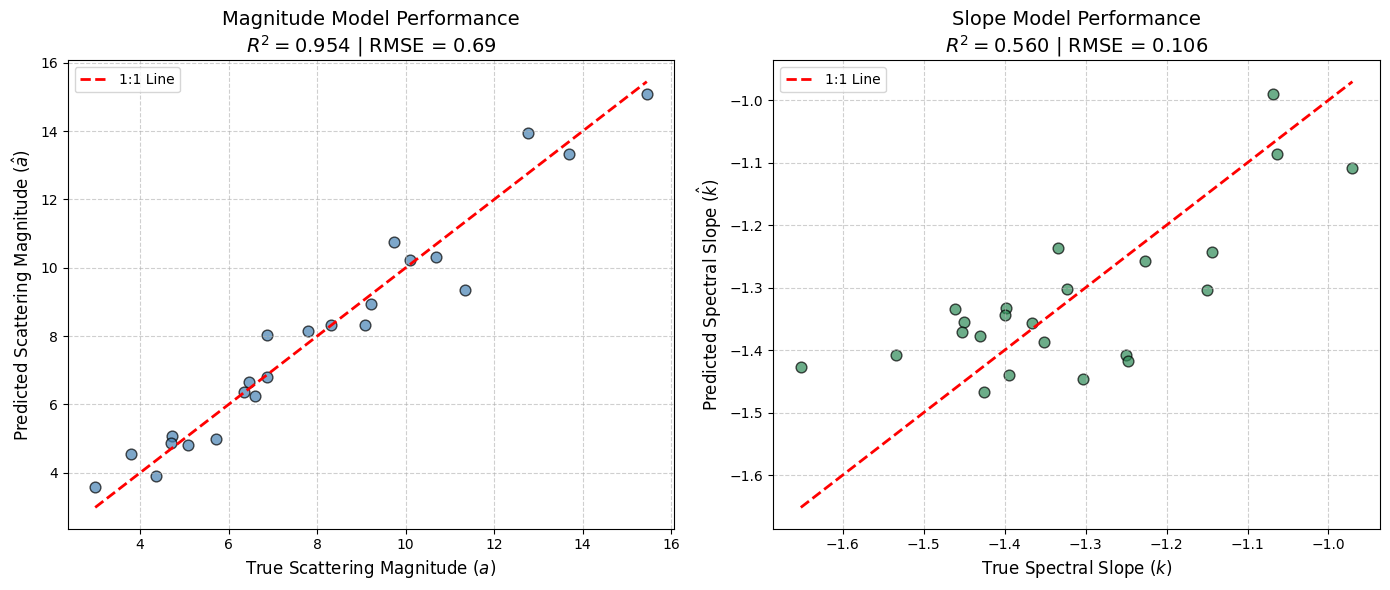

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Two features are needed
feature1 = "tss_mg_l"
feature2 = "doc_04u_mg_l"
res_df_clean = spectra_merged_df.dropna(subset=[feature1, feature2, "scattering_magnitude", "slope"])

# magnitude model

X_magn = res_df_clean[[target_feature]].values
y_magn = res_df_clean['scattering_magnitude'].values
magnitude_model = LinearRegression()
magnitude_model.fit(X_magn, y_magn)
y_magn_pred = magnitude_model.predict(X_magn)

# slope model (the optimal single feasture is a ratio)
X_slope = np.array(res_df_clean[feature1] / res_df_clean[feature2].replace(0, np.nan)).reshape(-1, 1)
y_slope = res_df_clean['slope']
slope_model = LinearRegression()
slope_model.fit(X_slope, y_slope)
y_slope_pred = slope_model.predict(X_slope)

# 2. Plotting Performance (Parity Plots)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Magnitude Model Performance ---
ax[0].scatter(y_magn, y_magn_pred, color='steelblue', alpha=0.7, edgecolors='k', s=60)
# 1:1 Line
lims_magn = [np.min([y_magn.min(), y_magn_pred.min()]), np.max([y_magn.max(), y_magn_pred.max()])]
ax[0].plot(lims_magn, lims_magn, 'r--', lw=2, label='1:1 Line')

r2_m = r2_score(y_magn, y_magn_pred)
rmse_m = np.sqrt(mean_squared_error(y_magn, y_magn_pred))

ax[0].set_title(f'Magnitude Model Performance\n$R^2 = {r2_m:.3f}$ | RMSE = {rmse_m:.2f}', fontsize=14)
ax[0].set_xlabel('True Scattering Magnitude ($a$)', fontsize=12)
ax[0].set_ylabel('Predicted Scattering Magnitude ($\hat{a}$)', fontsize=12)
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].legend()

# --- Plot 2: Slope Model Performance ---
ax[1].scatter(y_slope, y_slope_pred, color='seagreen', alpha=0.7, edgecolors='k', s=60)
# 1:1 Line
lims_slope = [np.min([y_slope.min(), y_slope_pred.min()]), np.max([y_slope.max(), y_slope_pred.max()])]
ax[1].plot(lims_slope, lims_slope, 'r--', lw=2, label='1:1 Line')

r2_s = r2_score(y_slope, y_slope_pred)
rmse_s = np.sqrt(mean_squared_error(y_slope, y_slope_pred))

ax[1].set_title(f'Slope Model Performance\n$R^2 = {r2_s:.3f}$ | RMSE = {rmse_s:.3f}', fontsize=14)
ax[1].set_xlabel('True Spectral Slope ($k$)', fontsize=12)
ax[1].set_ylabel('Predicted Spectral Slope ($\hat{k}$)', fontsize=12)
ax[1].grid(True, linestyle='--', alpha=0.6)
ax[1].legend()

plt.tight_layout()
plt.show()

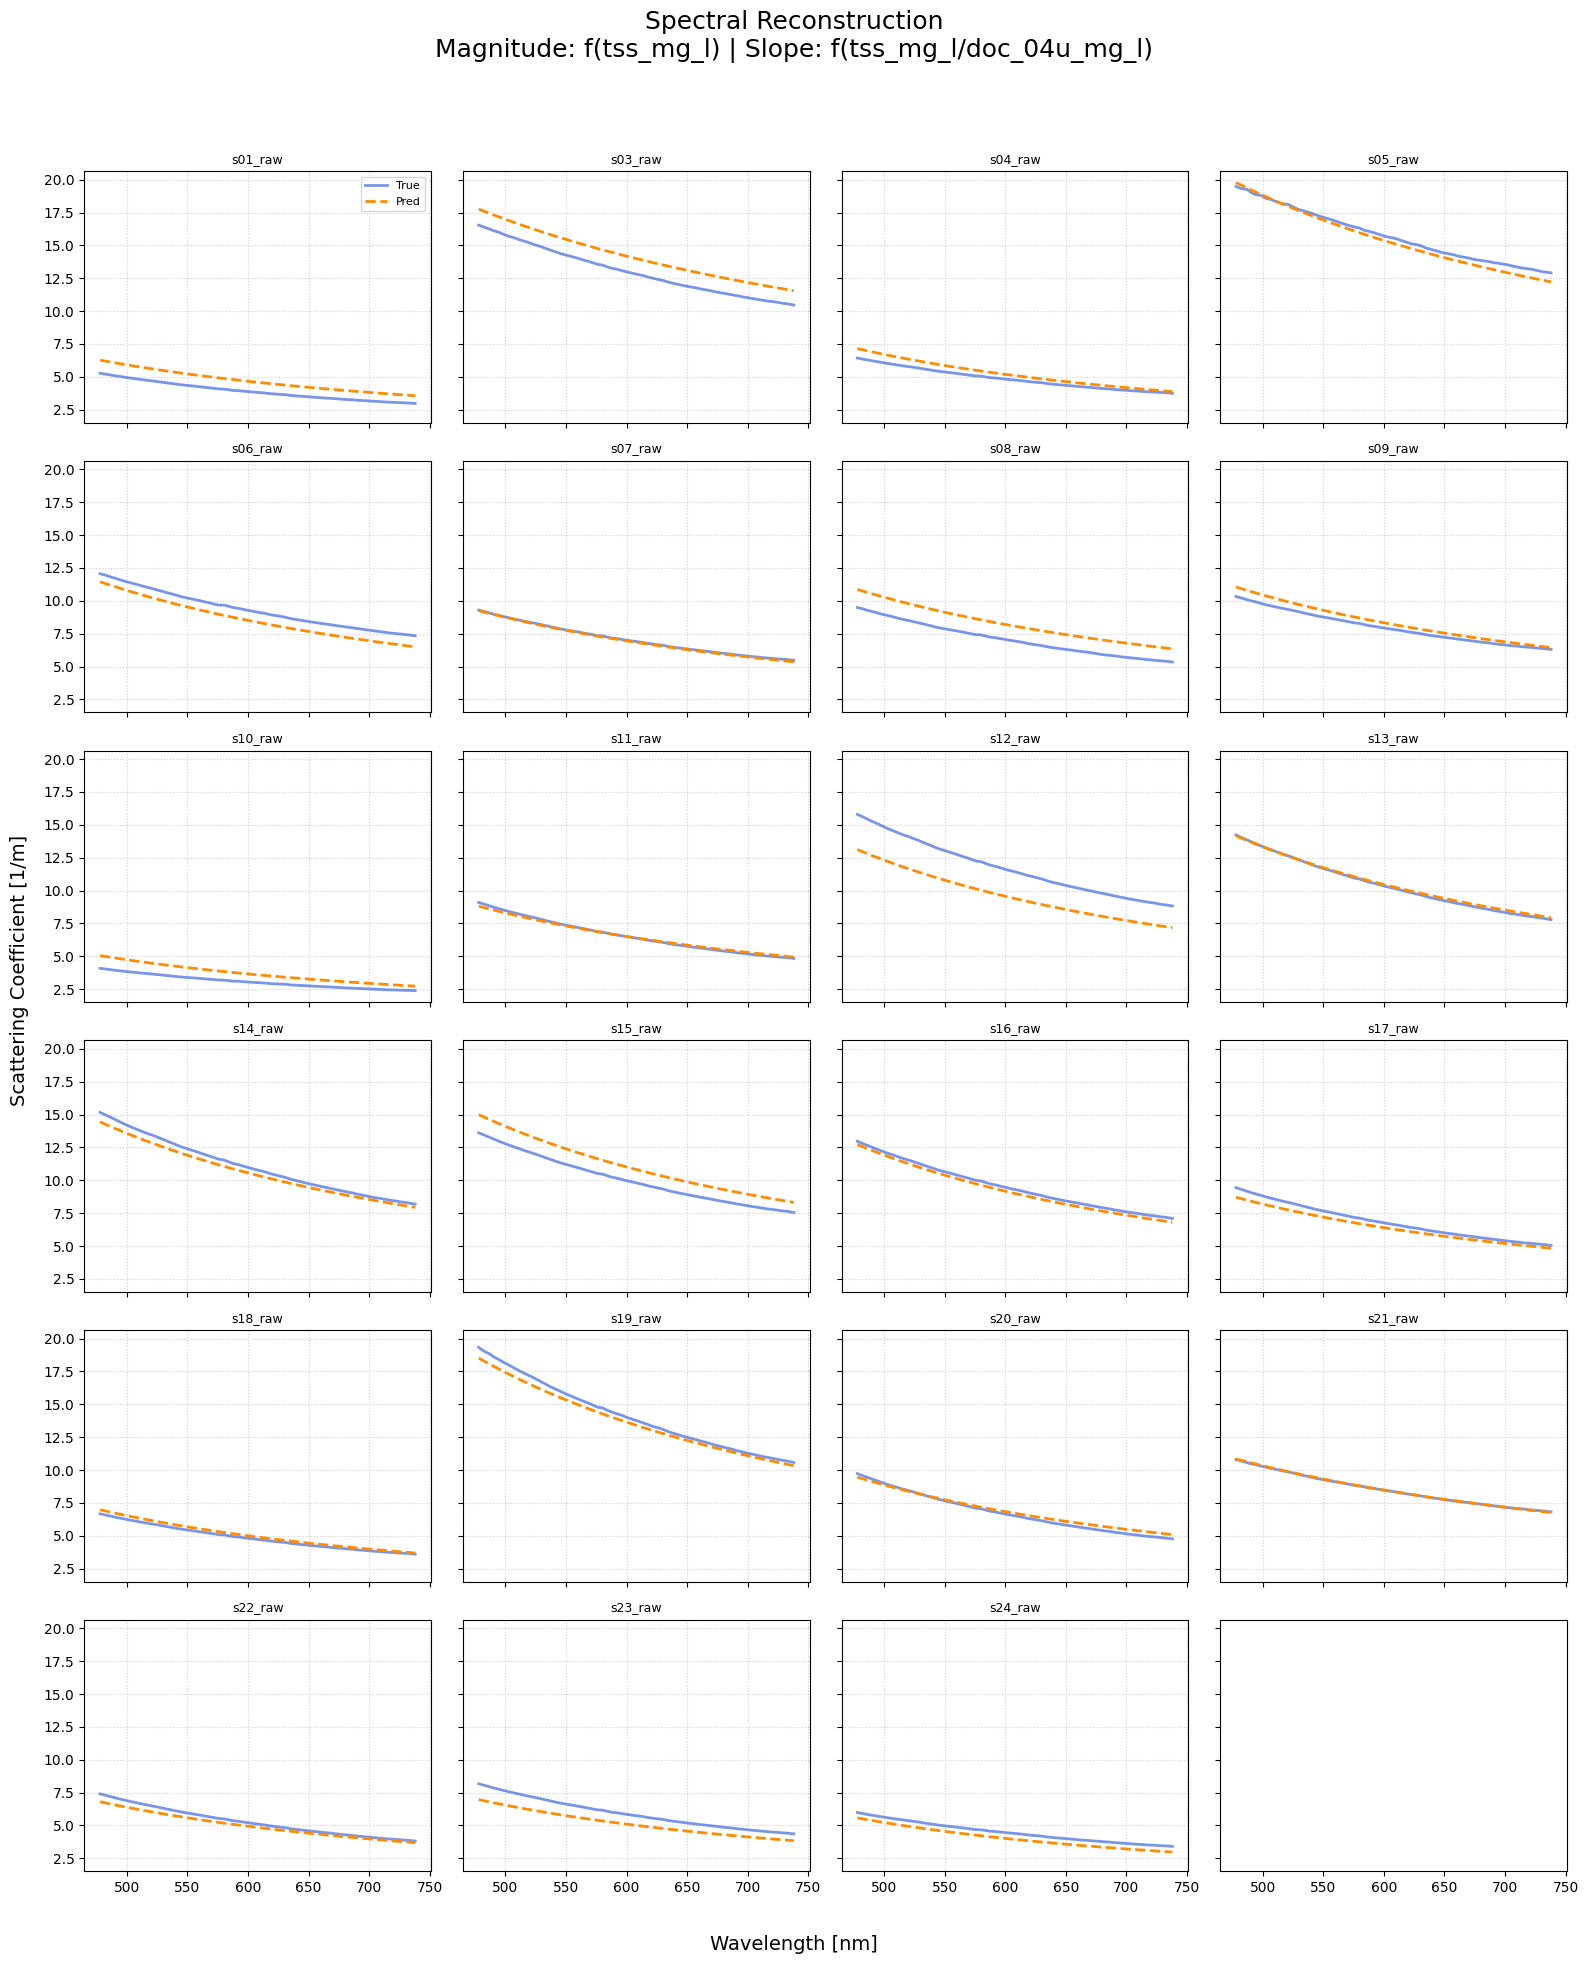

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup the Grid
# 6 rows, 4 columns = 24 total subplots
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(16, 20), sharex=True, sharey=True)
axes_flat = axes.flatten()

# Reference wavelength for the power law
wav_ref = np.mean(wav_B)

# 2. Iterate through your 24 samples
for i, (idx, sample_data) in enumerate(res_df_clean.iterrows()):
    if i >= 24: break
    
    # --- TRUE DATA ---
    true_y = sample_data[sp_cols_B].values.astype(float)
    
    # --- PREDICTIONS ---
    # Magnitude Prediction (Scattering at wav_ref)
    # Ensure X is 2D for the model: [[value]]
    x_m_val = np.array([[sample_data[feature1]]])
    pred_magnitude = magnitude_model.predict(x_m_val)[0]
    
    # Slope Prediction (k)
    # Calculate the ratio TSS/DOC for this specific sample
    ratio_val = sample_data[feature1] / sample_data[feature2]
    x_s_val = np.array([[ratio_val]])
    pred_slope = slope_model.predict(x_s_val)[0]
    
    # Reconstruct the curve: y = a * (lambda / lambda_ref)^k
    # This is the physical Power Law form
    reconstructed_y = pred_magnitude * (wav_B / wav_ref)**pred_slope
    
    # --- PLOTTING ---
    ax = axes_flat[i]
    
    # Plot true vs predicted
    ax.plot(wav_B, true_y, color="royalblue", lw=2, label="True", alpha=0.7)
    ax.plot(wav_B, reconstructed_y, color="darkorange", linestyle="--", lw=2, label="Pred")
    
    # Labeling
    # Shorten the sample name if it's too long for the subplot title
    title_name = str(sample_data["full_sample_name"])[-15:] 
    ax.set_title(f"{title_name}", fontsize=9)
    
    # Add legend only to the first plot to save space
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)
    
    ax.grid(True, linestyle=':', alpha=0.6)

# 3. Global Styling
plt.suptitle(f"Spectral Reconstruction\nMagnitude: f({feature1}) | Slope: f({feature1}/{feature2})", 
             fontsize=18, y=0.98)

# Add shared axis labels
fig.text(0.5, 0.01, 'Wavelength [nm]', ha='center', fontsize=14)
fig.text(0.01, 0.5, 'Scattering Coefficient [1/m]', va='center', rotation='vertical', fontsize=14)

plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
plt.show()

<>:43: SyntaxWarning: invalid escape sequence '\p'
<>:43: SyntaxWarning: invalid escape sequence '\p'
C:\Users\pierr\AppData\Local\Temp\ipykernel_3240\2897166855.py:43: SyntaxWarning: invalid escape sequence '\p'
  alpha=0.7, label='Sample Mean $\pm$ SD')


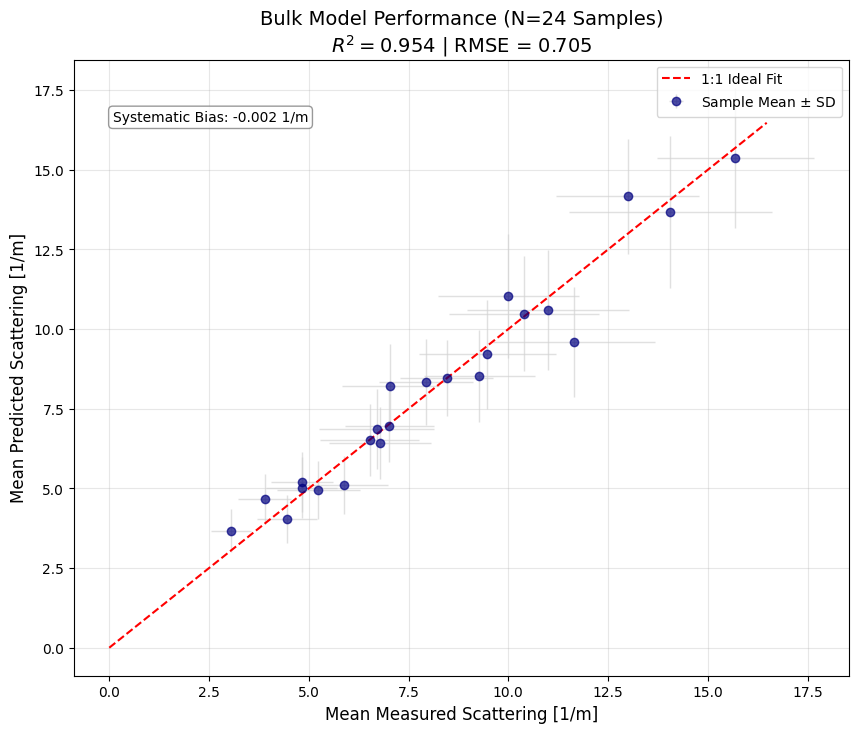

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

sample_means_true = []
sample_means_pred = []
sample_stds_true = []
sample_stds_pred = []

for i, (idx, sample_data) in enumerate(res_df_clean.iterrows()):
    # Get True Spectrum
    true_y = sample_data[sp_cols_B].values.astype(float)
    
    # Calculate Prediction
    x_m_val = np.array([[sample_data[feature1]]])
    pred_magnitude = magnitude_model.predict(x_m_val)[0]
    
    ratio_val = sample_data[feature1] / sample_data[feature2]
    pred_slope = slope_model.predict(np.array([[ratio_val]]))[0]
    reconstructed_y = pred_magnitude * (wav_B / wav_ref)**pred_slope
    
    # Calculate Means and Stds for this specific sample
    sample_means_true.append(np.mean(true_y))
    sample_means_pred.append(np.mean(reconstructed_y))
    sample_stds_true.append(np.std(true_y))
    sample_stds_pred.append(np.std(reconstructed_y))

# Convert to arrays for metrics
sample_means_true = np.array(sample_means_true)
sample_means_pred = np.array(sample_means_pred)

# Calculate Metrics
r2_bulk = r2_score(sample_means_true, sample_means_pred)
rmse_bulk = np.sqrt(mean_squared_error(sample_means_true, sample_means_pred))

# Plotting
plt.figure(figsize=(10, 8))

# Error bars represent the spectral variation (the "spread" caused by the slope)
plt.errorbar(sample_means_true, sample_means_pred, 
             xerr=sample_stds_true, yerr=sample_stds_pred,
             fmt='o', color='navy', ecolor='lightgray', elinewidth=1, capsize=0, 
             alpha=0.7, label='Sample Mean $\pm$ SD')

# 1:1 Reference Line
lims = [0, max(sample_means_true.max(), sample_means_pred.max()) * 1.05]
plt.plot(lims, lims, color='red', linestyle='--', label='1:1 Ideal Fit')

plt.title(f"Bulk Model Performance (N=24 Samples)\n$R^2 = {r2_bulk:.3f}$ | RMSE = {rmse_bulk:.3f}", fontsize=14)
plt.xlabel("Mean Measured Scattering [1/m]", fontsize=12)
plt.ylabel("Mean Predicted Scattering [1/m]", fontsize=12)

# Annotation for bias
bias = np.mean(sample_means_pred - sample_means_true)
plt.annotate(f"Systematic Bias: {bias:.3f} 1/m", xy=(0.05, 0.9), xycoords='axes fraction',
             bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

single param model, mean slope

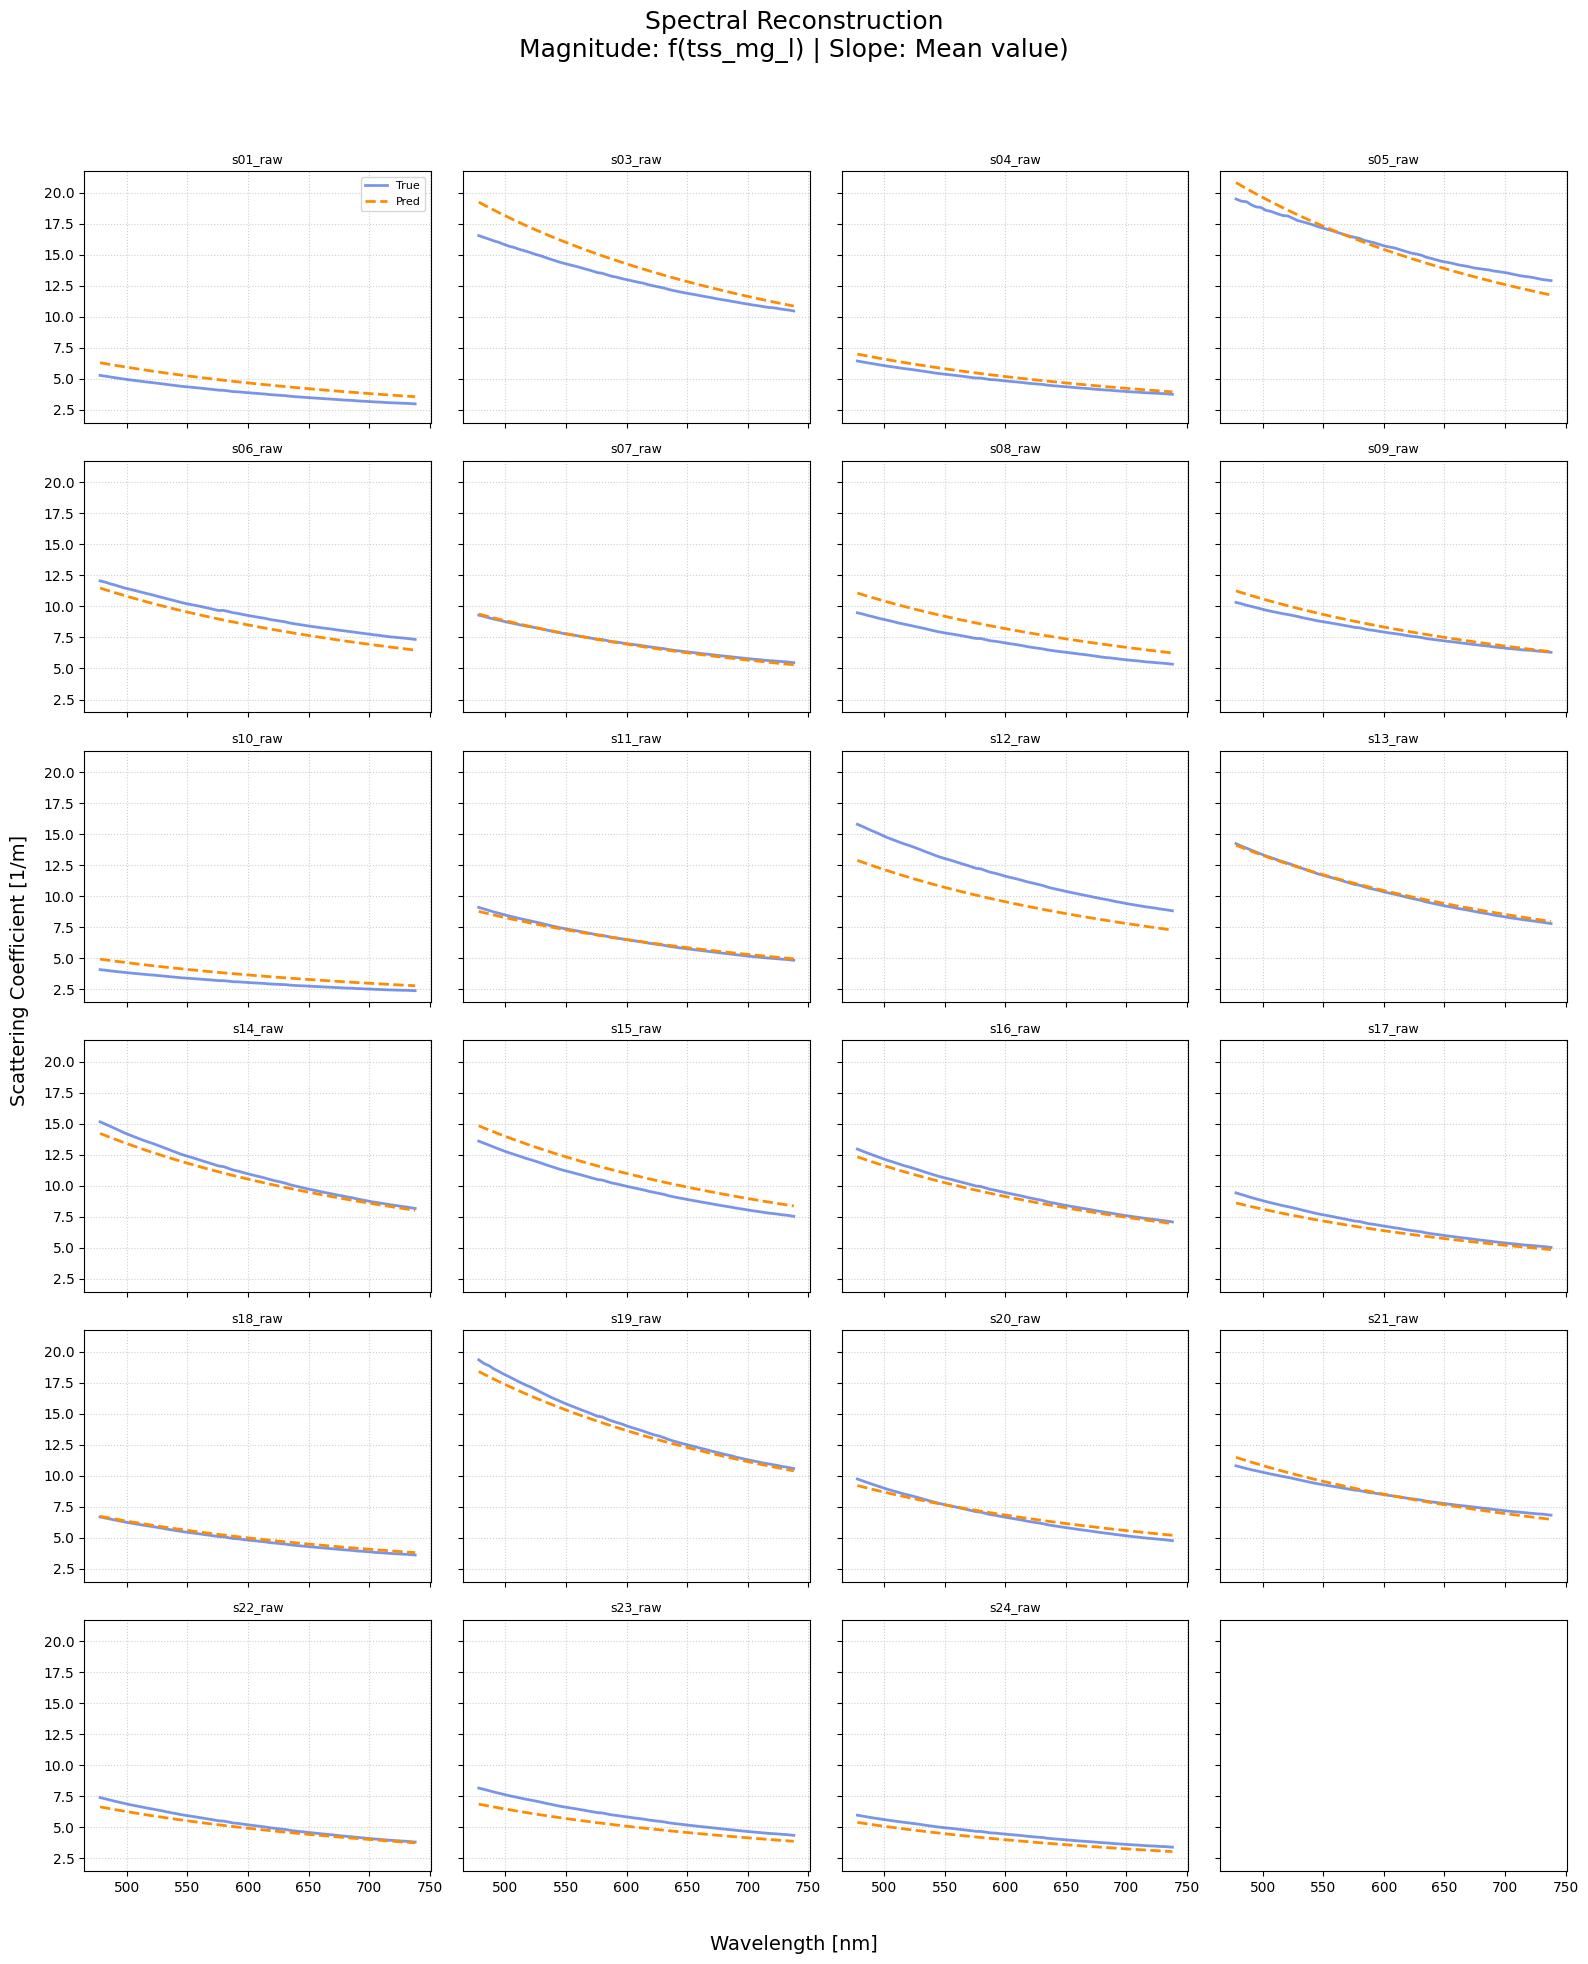

In [75]:
import numpy as np
import matplotlib.pyplot as plt

mean_slope = spectra_merged_df["slope"].mean()

# 1. Setup the Grid
# 6 rows, 4 columns = 24 total subplots
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(16, 20), sharex=True, sharey=True)
axes_flat = axes.flatten()

# Reference wavelength for the power law
wav_ref = np.mean(wav_B)

# 2. Iterate through your 24 samples
for i, (idx, sample_data) in enumerate(res_df_clean.iterrows()):
    if i >= 24: break
    
    # --- TRUE DATA ---
    true_y = sample_data[sp_cols_B].values.astype(float)
    
    # --- PREDICTIONS ---
    # Magnitude Prediction (Scattering at wav_ref)
    # Ensure X is 2D for the model: [[value]]
    x_m_val = np.array([[sample_data[feature1]]])
    pred_magnitude = magnitude_model.predict(x_m_val)[0]
        
    # Reconstruct the curve: y = a * (lambda / lambda_ref)^k
    # This is the physical Power Law form
    reconstructed_y = pred_magnitude * (wav_B / wav_ref)**mean_slope
    
    # --- PLOTTING ---
    ax = axes_flat[i]
    
    # Plot true vs predicted
    ax.plot(wav_B, true_y, color="royalblue", lw=2, label="True", alpha=0.7)
    ax.plot(wav_B, reconstructed_y, color="darkorange", linestyle="--", lw=2, label="Pred")
    
    # Labeling
    # Shorten the sample name if it's too long for the subplot title
    title_name = str(sample_data["full_sample_name"])[-15:] 
    ax.set_title(f"{title_name}", fontsize=9)
    
    # Add legend only to the first plot to save space
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)
    
    ax.grid(True, linestyle=':', alpha=0.6)

# 3. Global Styling
plt.suptitle(f"Spectral Reconstruction\nMagnitude: f({feature1}) | Slope: Mean value)", 
             fontsize=18, y=0.98)

# Add shared axis labels
fig.text(0.5, 0.01, 'Wavelength [nm]', ha='center', fontsize=14)
fig.text(0.01, 0.5, 'Scattering Coefficient [1/m]', va='center', rotation='vertical', fontsize=14)

plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
plt.show()

<>:43: SyntaxWarning: invalid escape sequence '\p'
<>:43: SyntaxWarning: invalid escape sequence '\p'
C:\Users\pierr\AppData\Local\Temp\ipykernel_3240\3528426813.py:43: SyntaxWarning: invalid escape sequence '\p'
  alpha=0.7, label='Sample Mean $\pm$ SD')


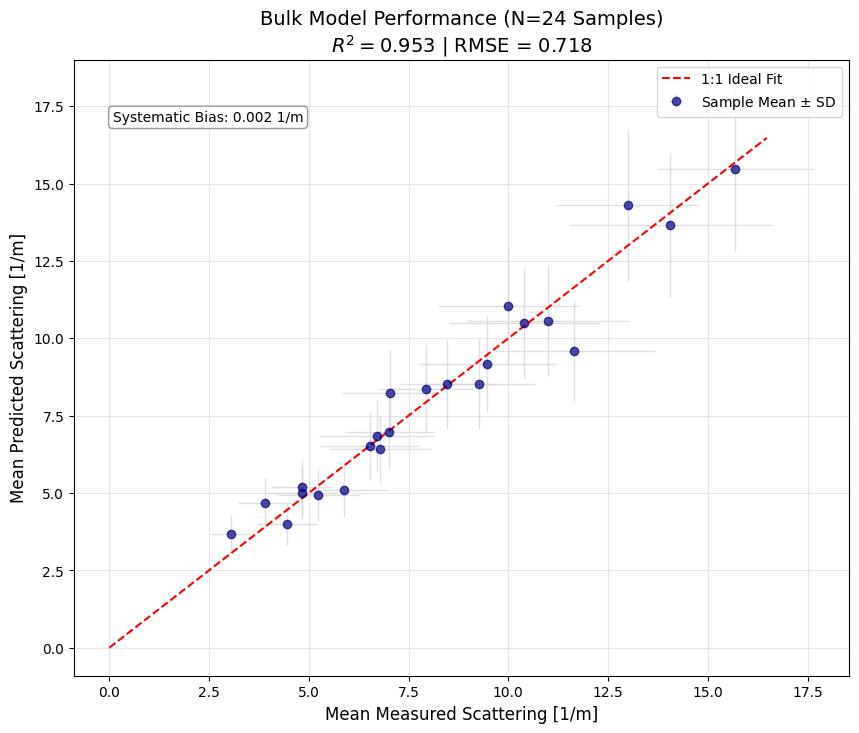

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

mean_slope = spectra_merged_df["slope"].mean()

sample_means_true = []
sample_means_pred = []
sample_stds_true = []
sample_stds_pred = []

for i, (idx, sample_data) in enumerate(res_df_clean.iterrows()):
    # Get True Spectrum
    true_y = sample_data[sp_cols_B].values.astype(float)
    
    # Calculate Prediction
    x_m_val = np.array([[sample_data[feature1]]])
    pred_magnitude = magnitude_model.predict(x_m_val)[0]
    
    reconstructed_y = pred_magnitude * (wav_B / wav_ref)**mean_slope
    
    # Calculate Means and Stds for this specific sample
    sample_means_true.append(np.mean(true_y))
    sample_means_pred.append(np.mean(reconstructed_y))
    sample_stds_true.append(np.std(true_y))
    sample_stds_pred.append(np.std(reconstructed_y))

# Convert to arrays for metrics
sample_means_true = np.array(sample_means_true)
sample_means_pred = np.array(sample_means_pred)

# Calculate Metrics
r2_bulk = r2_score(sample_means_true, sample_means_pred)
rmse_bulk = np.sqrt(mean_squared_error(sample_means_true, sample_means_pred))

# Plotting
plt.figure(figsize=(10, 8))

# Error bars represent the spectral variation (the "spread" caused by the slope)
plt.errorbar(sample_means_true, sample_means_pred, 
             xerr=sample_stds_true, yerr=sample_stds_pred,
             fmt='o', color='navy', ecolor='lightgray', elinewidth=1, capsize=0, 
             alpha=0.7, label='Sample Mean $\pm$ SD')

# 1:1 Reference Line
lims = [0, max(sample_means_true.max(), sample_means_pred.max()) * 1.05]
plt.plot(lims, lims, color='red', linestyle='--', label='1:1 Ideal Fit')

plt.title(f"Bulk Model Performance (N=24 Samples)\n$R^2 = {r2_bulk:.3f}$ | RMSE = {rmse_bulk:.3f}", fontsize=14)
plt.xlabel("Mean Measured Scattering [1/m]", fontsize=12)
plt.ylabel("Mean Predicted Scattering [1/m]", fontsize=12)

# Annotation for bias
bias = np.mean(sample_means_pred - sample_means_true)
plt.annotate(f"Systematic Bias: {bias:.3f} 1/m", xy=(0.05, 0.9), xycoords='axes fraction',
             bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()